# Three-point functions of operators with spin on the cylinder

This notebook analyses the three-point structure constants computed by the C++ program and compares it to the analytic prediction

$$
\begin{align}
\boxed{C^\text{ref}_{(r_1,s_1)(r_2,s_2)(r_3,s_3)} =\prod_{\epsilon_1,\epsilon_2,\epsilon_3=\pm} \Gamma_\beta^{-1} \left(\tfrac{\beta+\beta^{-1}}{2} + \tfrac{\beta}{2}\left|\textstyle{\sum_i} \epsilon_ir_i\right| + \tfrac{\beta^{-1}}{2}\textstyle{\sum_i} \epsilon_is_i\right)}\ .
\end{align}
$$

We will use the short notation $C_{123} = C^{\text{ref}}_{(r_1,s_1)(r_2,s_2)(r_3,s_3)}$, and let an index $0$ denote an insertion of the identity operator which in our conventions has indices $(0, 2\beta P_{(1, 1)})$.

The quantity we want to compute with the lattice prediction is the ratio

$$
\omega_{123} = \frac{C_{123} \sqrt{C_{000}}}{\sqrt{C_{101}C_{202}C_{303}}}
$$

## CFT prediction

In [1]:
# install necessary dependencies
using Pkg; Pkg.activate(".");

using BarnesDoubleGamma,
    Plots,
    JLD2,
    LaTeXStrings,
    DelimitedFiles,
    BootstrapVirasoro

import Polynomials.fit,
    LinearAlgebra.dot,
    IterTools.product
import DataFrames: DataFrame
import GLM: lm, @formula, coef

# go to the results directory
cd("../results")

  Activating project at `~/Documents/Recherche/projet_these/code/transfer_matrices/TransferMatricesCpp/On_loops/julia_notebooks`


In [2]:
function Cref(c::CentralCharge, ri, si)
    β = abs(c.β)
    return prod(
        inv(doublegamma(
            (β+inv(β))/2 + β/2*abs(dot(e, ri)) + inv(β)/2*dot(e, si),
            β,
            tol = 1e-6
        ))
        for e in product((-1, 1), (-1, 1), (-1, 1))
    )
end

P11(c) = ConformalDimension(c, :Δ, 0).P

function omega(c::CentralCharge, ri, si)
    β = abs(c.β)
    C123 = Cref(c, ri, si)
    C101 = Cref(c, (ri[1], 0, ri[1]), (si[1], 2*β*P11(c), si[1]))
    C202 = Cref(c, (ri[2], 0, ri[2]), (si[2], 2*β*P11(c), si[2]))
    C303 = Cref(c, (ri[3], 0, ri[3]), (si[3], 2*β*P11(c), si[3]))
    C220 = Cref(c, (ri[2], ri[2], 0), (si[2], si[2], 2*β*P11(c)))
    C000 = Cref(c, (0, 0, 0), (2*β*P11(c), 2*β*P11(c), 2*β*P11(c)))

    C123*sqrt(C000/C101/C303/C202)
end

omega(c::CentralCharge, i1, i2, i3) = omega(c, (i1[1], i2[1], i3[1]), (i1[2], i2[2], i3[2]))
omega(s::Symbol, x, i1, i2, i3) = omega(CentralCharge(s, x), i1, i2, i3)

# check that the value is right for percolation
println(isapprox(omega(:β, sqrt(2/3), (1, 0), (1, 0), (1, 0)), 0.9523590967841016697715))

true


In [22]:
c = CentralCharge(β = 1/sqrt(3))
Cref(c, (0, 0, 0), (2*c.β*P11(c), 2*c.β*P11(c), 2*c.β*P11(c)))

-7.885952923043861e-17 + 9.657507005432378e-33im

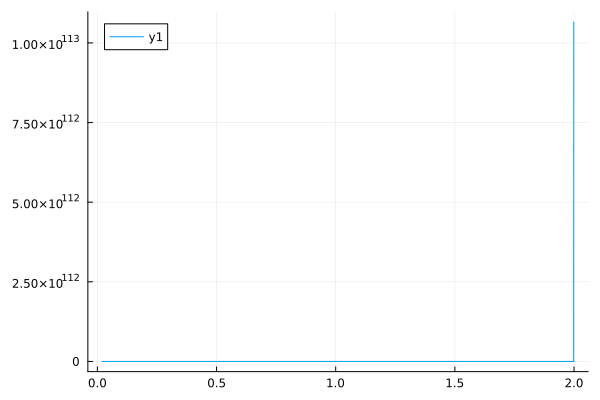

In [23]:
cs = [CentralCharge(β = β) for β in 0.1:0.01:2]

plot([abs(n(c)) for c in cs], [abs(Cref(c, (0, 0, 0), (2*c.β*P11(c), 2*c.β*P11(c), 2*c.β*P11(c)))) for c in cs])

In [14]:
ϵ = 1e-15
setprecision(BigFloat, 25, base=10)
c = CentralCharge(β = sqrt(big"2") + ϵ)
n(c) = -2cos(π * c.β^2)

test(r) = omega(c, (r, 0), (r, 0), (1, 0)) / sqrt(n(c))

test (generic function with 1 method)

In [15]:
for r in 0.5:0.5:10
    println(test(r))
end

0.0 - 3.8602902950956124068764111e-08im
0.0 - 6.23430238751013452975146719e-08im
0.0 - 8.37148573904975174921981409e-08im
0.0 - 1.03511093938973715306457595e-07im
0.0 - 1.22164409464143669212763982e-07im
0.0 - 1.39936617061385126277017629e-07im
0.0 - 1.56999965073785668859705848e-07im
0.0 - 1.73475066642285744560687503e-07im
0.0 - 1.89450463848016563164613708e-07im
0.0 - 2.04993590856251263380566766e-07im
0.0 - 2.20157338372664942208109097e-07im
0.0 - 2.34984200088461652957353894e-07im
0.0 - 2.49509008913682514000863264e-07im
0.0 - 2.63760809475427094810893991e-07im
0.0 - 2.77764179411548801347143424e-07im
0.0 - 2.91540186424915626276995199e-07im
0.0 - 3.05107097332015285331384318e-07im
0.0 - 3.18480913806586369187994027e-07im
0.0 - 3.31675784235953174011172165e-07im
0.0 - 3.44704325223787942987739933e-07im


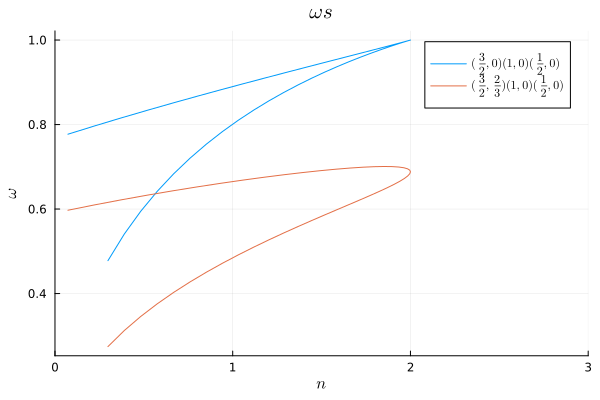

In [3]:
cs = [CentralCharge(:β, β) for β in 0.74:0.01:sqrt(1.5)]
ns = real.([c.n for c in cs])

plot(xrange = (0, 3), xlabel = L"n", ylabel = L"ω", title=L"ωs")
# omegas = real.([omega(c, (1, 0), (1, 0), (1, 0)) for c in cs])
# plot!(ns, omegas, label=L"(1,0)^3")
# omegas = real.([omega(c, (1, 1), (1, 0), (1, 0)) for c in cs])
# plot!(ns, omegas, label=L"(1, 1)(1, 0)^2")
# omegas = real.([omega(c, (1, 1), (1, 1), (1, 0)) for c in cs])
# plot!(ns, omegas, label=L"(1, 1)^2(1, 0)")
# omegas = real.([omega(c, (1, 1), (1, 1), (1, 1)) for c in cs])
# plot!(ns, omegas, label=L"(1, 1)^3")
omegas = real.([omega(c, (3//2, 0), (1, 0), (1//2, 0)) for c in cs])
plot!(ns, omegas, label=L"(\frac{3}{2}, 0)(1, 0)(\frac{1}{2}, 0)")
omegas = real.([omega(c, (3//2, 2//3), (1, 0), (1//2, 0)) for c in cs])
plot!(ns, omegas, label=L"(\frac{3}{2}, \frac{2}{3})(1, 0)(\frac{1}{2}, 0)")
display(plot!())

## Lattice results

### $(1, 0)(1, 0)(1, 0)$ WORKING

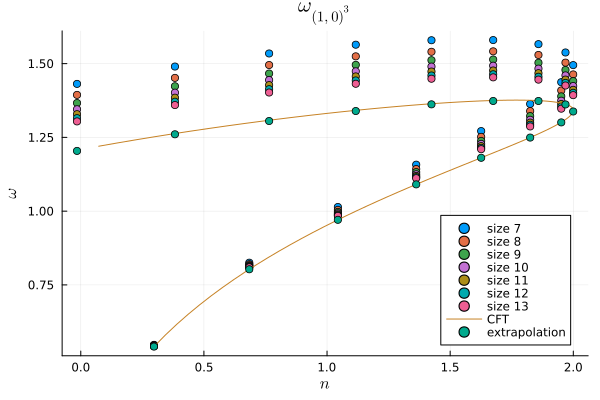

In [5]:
output_dict = load("3pt_10_10_10.jld2", "data")
c123s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c202020"]), '\t')[:, 3])
c101s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c200020"]), '\t')[:, 3])
c220s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c202000"]), '\t')[:, 3])
c000s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c000000"]), '\t')[:, 3])
ns_lattice = readdlm(IOBuffer(output_dict[5]["c202020"]), '\t')[:, 2]
ω_lattice(L) = c123s(L) .* sqrt.(c000s(L) ./ c101s(L)) ./ c220s(L)

# plot lattice data
plt = plot(xlabel = L"n", ylabel = L"ω", title=L"ω_{(1, 0)^3}")
for L in 7:13
    try
        scatter!(ns_lattice, ω_lattice(L), label="size $L")
    catch
        nothing
    end
end

# CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (1, 0), (1, 0), (1, 0)) for c in cs])
plot!(ns, ω_CFT, label="CFT")

# Extrapolation
om(L, i) = ω_lattice(L)[i]
Ls = 5:13
poly_fit(i) = fit(1 ./ Ls, [om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]
scatter!(ns_lattice, extrapolated_points, label="extrapolation")
# savefig("exported_figures/omega101010.pdf")
display(plt)

In [6]:
# relative difference
λs = 0.43:0.05:sqrt(1.5)
βs = sqrt.(4/π .* λs)
omegas = real.([omega(CentralCharge(:β, β), (1, 0), (1, 0), (1, 0)) for β in βs])

diffs = abs.((omegas - extrapolated_points) ./ omegas)
maximum(diffs)

0.00204516173045854694668418604147481823270319206938236598990652450469784915008019

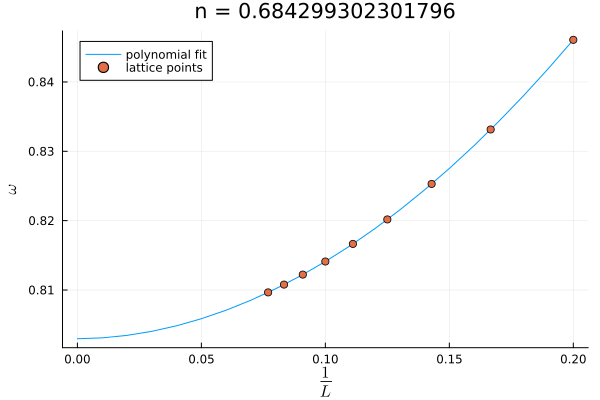

In [7]:
mesh=0:0.01:0.2
i=2
plt = plot(mesh, poly_fit(i).(mesh), label="polynomial fit")
scatter!(1 ./ Ls, [om(L, i) for L in Ls], label="lattice points")
plot!(xlabel=L"\frac{1}{L}", ylabel=L"\omega")
plot!(title="n = $(ns_lattice[i])")
display(plt)

### $(1, 1)(1, 0)^2$ WORKING - FACTORS TO UNDERSTAND

In [8]:
ω_lattice(5)

16-element Vector{BigFloat}:
 0.5526536715638053693579987728214861256670180101627748903052075785283667325039168
 0.8460724290825756537684959290731155178726584642925401751864818119244761923006388
 1.053234186912834910915113230203366782600660833265193845225835612614871728165123
 1.215623060964540909141135778678005075823898001035784428364049882374122859771401
 1.347671341566696372754236497927961270663857415016819281187387603759945355080952
 1.456067892345803481961037303885095944473112099250129068531004739337655633626248
 1.544235624409639779767993667329461925521231913976797200633815344513171790449048
 1.613973651814985652997426708894176838602775603595820191159501488519906616418394
 1.666209694719875426991736076219585436184171920765630460545731310810100127972735
 1.701396383352036723445805019294714890851512136899546422921944399475678740278879
 1.719742277525683961133802833694965356802334763937688235887051270220156076880389
 1.7213563110754143763624059316400615705857708966289235829149908841

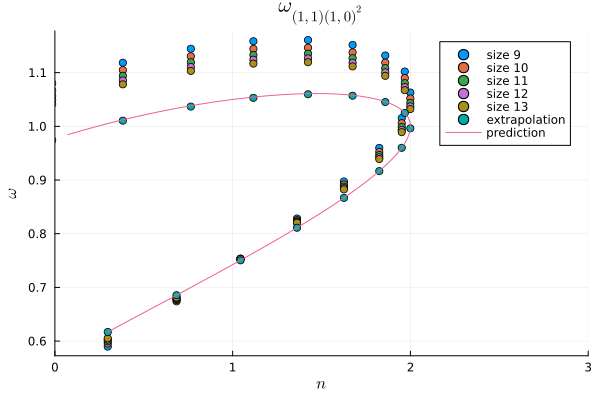

In [9]:
output_dict = load("3pt_11_10_10.jld2", "data")
c123s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c212020"]), '\t')[:, 3])
c101s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c210021"]), '\t')[:, 3])
c220s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c202000"]), '\t')[:, 3])
c000s(L) = BigFloat.(readdlm(IOBuffer(output_dict[L]["c000000"]), '\t')[:, 3])
ns_lattice = readdlm(IOBuffer(output_dict[5]["c000000"]), '\t')[:, 2]
ω_lattice(L) = .- c123s(L) .* sqrt.(c000s(L) ./ c101s(L)) ./ c220s(L)

Lrange = 8:13

om(L, i) = ω_lattice(L)[i]
Ls = 5:13
poly_fit(i) = fit(1 ./ (Ls), [L*om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]

# plot lattice data
plt = plot(xrange = (0, 3), xlabel = L"n", ylabel = L"ω", title=L"ω_{(1, 1)(1, 0)^2}")
for L in Lrange
    try
        if L > 8
        scatter!(ns_lattice, L .* ω_lattice(L) ./ poly_fit(8)(0), label="size $L")
        end
    catch
        nothing
    end
end


scatter!(ns_lattice, extrapolated_points ./ sqrt(2) ./ π, label="extrapolation")

# plot CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (1, 1), (1, 0), (1, 0)) for c in cs])
plot!(ns, ω_CFT, label="prediction")

savefig("exported_figures/omega_11_10_10.pdf")

display(plt)

In [10]:
# relative difference
λs = 0.43:0.05:sqrt(1.5)
βs = sqrt.(4/π .* λs)
omegas = real.([omega(CentralCharge(:β, β), (1, 1), (1, 0), (1, 0)) for β in βs])

diffs = abs.((omegas - extrapolated_points ./ sqrt(2) ./ π) ./ omegas)
maximum(diffs)

0.001598357030404080412450524891226905417900856060917306749569211881425439271449442

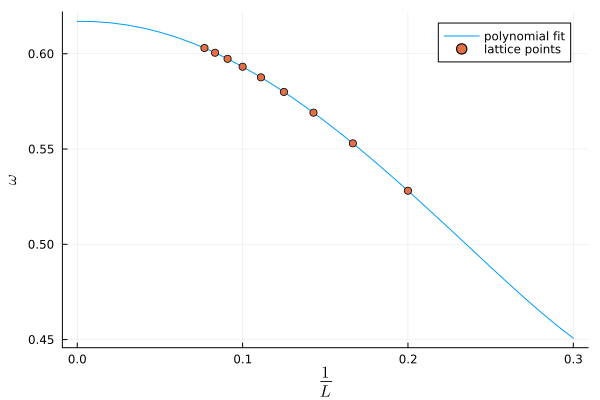

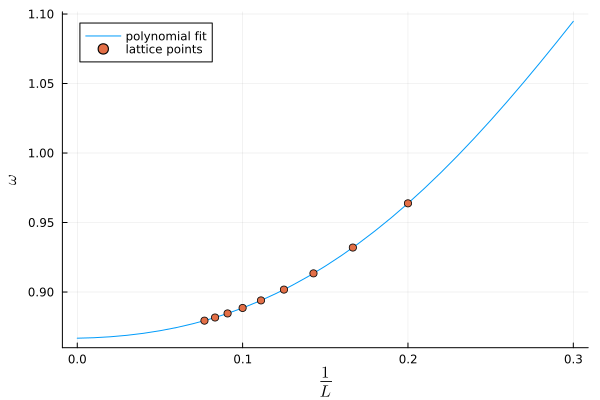

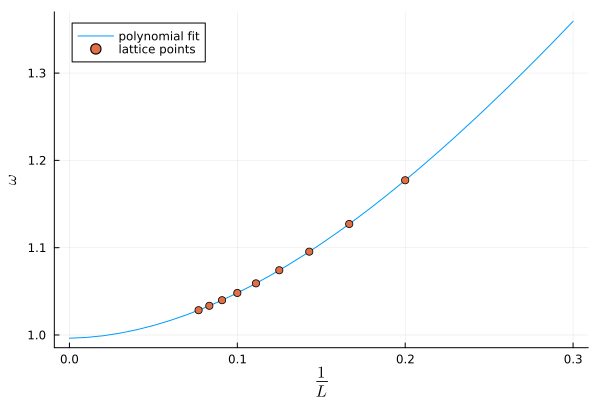

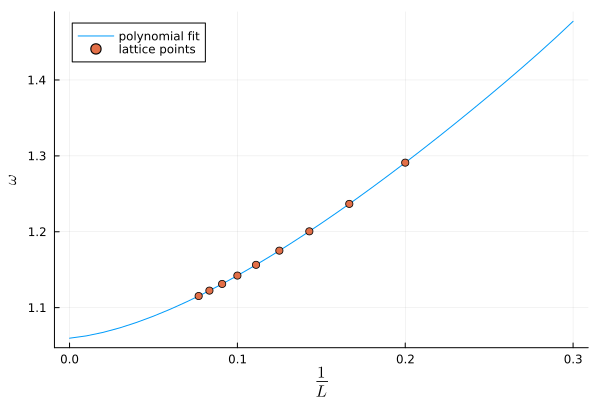

In [11]:
mesh=0:0.01:0.3
for i in (1, 5, 8, 12)
    lattice_points = [L * om(L, i) for L in Ls] ./ (sqrt(2) * π)
    poly_fit(i) = fit(1 ./ (Ls), lattice_points)
    # println(poly_fit(i)(0))
    p = plot(mesh, poly_fit(i).(mesh), label="polynomial fit")
    scatter!(1 ./ (Ls), lattice_points, label="lattice points")
    plot!(xlabel=L"\frac{1}{L}", ylabel=L"\omega")
    display(p)
end

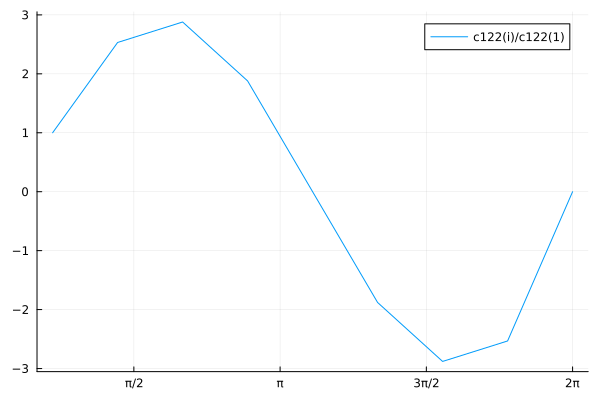

In [12]:
c122 = load("../results/move_bottom_insertion.jld2", "c122")
L = length(c122)
xticks = (0:π/2:2π, ["0", "π/2", "π", "3π/2", "2π"])
plot([2π*i/L for i in 1:L], c122./c122[1], xticks = xticks, label="c122(i)/c122(1)")
# savefig("exported_figures/c122_move_current_insertion.pdf")

In [13]:
c222 = load("../results/move_bottom_insertion_2leg.jld2", "c122")
L = length(c222)
xticks = (0:π/2:2π, ["0", "π/2", "π", "3π/2", "2π"])
plot([2π*i/L for i in 1:L], c222./c222[1], xticks = xticks, label="c222[i]/c222(1)")
savefig("exported_figures/c222_move_current_insertion.pdf")

"/Users/paulroux/Documents/Recherche/projet_these/code/transfer_matrices/TransferMatricesCpp/On_loops/results/exported_figures/c222_move_current_insertion.pdf"

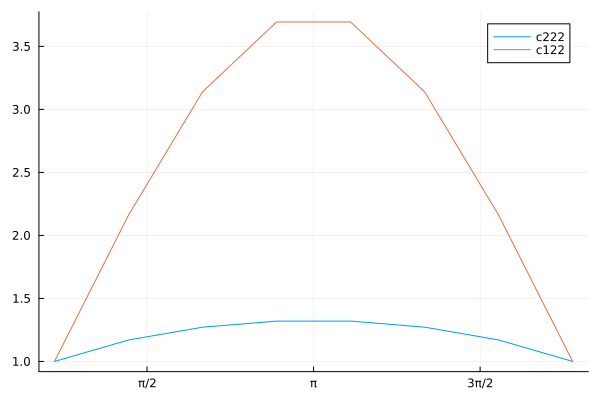

In [14]:
c122 = load("../results/move_bottom_insertion_sep.jld2", "c122")
c222 = load("../results/move_bottom_insertion_sep.jld2", "c222")
L = length(c222)
xticks = (0:π/2:2π, ["0", "π/2", "π", "3π/2", "2π"])
plot([2π*i/L for i in 1:L-1], c222[1:L-1]./c222[1], xticks = xticks, label="c222")
plot!([2π*i/L for i in 1:L-1], c122[1:L-1]./c122[1], label="c122")

### $(\frac{3}{2}, 0)(1, 0)(\frac{1}{2}, 0)$ WORKING

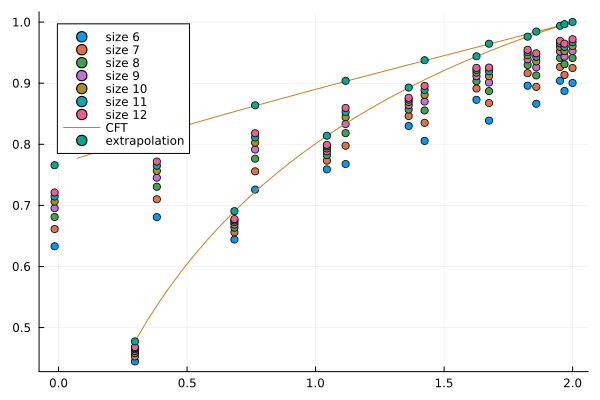

In [15]:
L = 5
res_file(L) = "../results/3pt/(3, 0)_(2, 0)_(1, 0)_size_$L.jld2"
λ_min = load(res_file(L), "λ_min")
λ_step = load(res_file(L), "λ_step")
nb_values_λ = load(res_file(L), "nb_values_λ")
λrange = range(λ_min, step=λ_step, length=nb_values_λ)
beta(λ) = sqrt(4*λ/π)
ccs = [CentralCharge(:β, beta(λ)) for λ in λrange]
ns_lattice = [real(c.n) for c in ccs]
ω_lattice(L) = load(res_file(L), "ωs")

scatter()

for L in 6:12
    try
        scatter!(ns_lattice, ω_lattice(L), label="size $L")
    catch
        nothing
    end
end

# plot CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (3//2, 0), (1, 0), (1//2, 0)) for c in cs])
plot!(ns, ω_CFT, label="CFT")

# Extrapolation
om(L, i) = ω_lattice(L)[i]
Ls = 5:12
poly_fit(i) = fit(1 ./ Ls, [om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]
scatter!(ns_lattice, extrapolated_points, label="extrapolation")

display(plot!())

### $(\frac{3}{2}, 0)(\frac{1}{2}, 0)(1, 0)$ WORKING

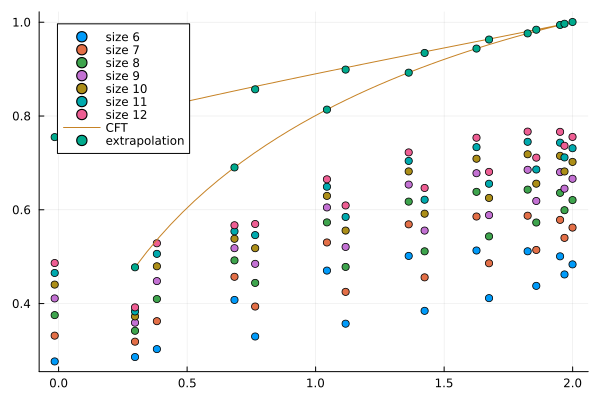

In [16]:
L = 6
res_file(L) = "../results/3pt/(3, 0)_(1, 0)_(2, 0)_size_$L.jld2"
λ_min = load(res_file(L), "λ_min")
λ_step = load(res_file(L), "λ_step")
nb_values_λ = load(res_file(L), "nb_values_λ")
λrange = range(λ_min, step=λ_step, length=nb_values_λ)
beta(λ) = sqrt(4*λ/π)
ccs = [CentralCharge(:β, beta(λ)) for λ in λrange]
ns_lattice = [real(c.n) for c in ccs]
ω_lattice(L) = load(res_file(L), "ωs")

scatter()

factor(L) = 2

for L in 6:12
    try
        scatter!(ns_lattice, factor(L)*ω_lattice(L), label="size $L")
    catch
        nothing
    end
end

# plot CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (3//2, 0), (1, 0), (1//2, 0)) for c in cs])
plot!(ns, ω_CFT, label="CFT")

# Extrapolation
om(L, i) = ω_lattice(L)[i]
Ls = 5:10
poly_fit(i) = fit(1 ./ Ls, [factor(L)*om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]
scatter!(ns_lattice, extrapolated_points, label="extrapolation")

display(plot!())

### $(1, 0)(\frac12, 0)(\frac32, 0)$ WORKING

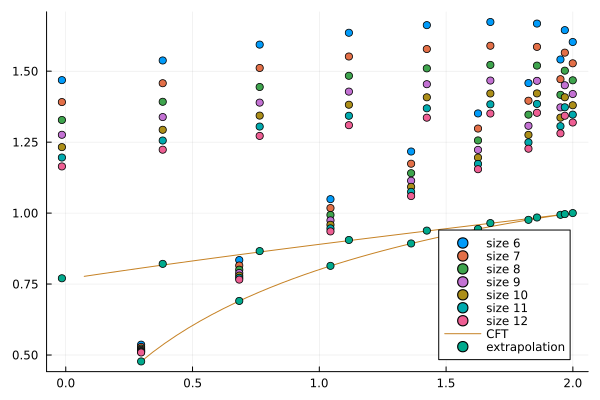

In [17]:
L = 6
r1, s1 = 1, 0
r2, s2 = 1//2, 0
r3, s3 = 3//2, 0
get_k_rs(r, s) = Int.((2*r, r*s))
res_file(L) = "../results/3pt/$(get_k_rs(r1, s1))_$(get_k_rs(r2, s2))_$(get_k_rs(r3, s3))_size_$L.jld2"
λ_min = load(res_file(L), "λ_min")
λ_step = load(res_file(L), "λ_step")
nb_values_λ = load(res_file(L), "nb_values_λ")
λrange = range(λ_min, step=λ_step, length=nb_values_λ)
beta(λ) = sqrt(4*λ/π)
ccs = [CentralCharge(:β, beta(λ)) for λ in λrange]
ns_lattice = [real(c.n) for c in ccs]
ω_lattice(L) = load(res_file(L), "ωs")

scatter()

factor(L) = 3

for L in 6:12
    try
        scatter!(ns_lattice, factor(L)*ω_lattice(L), label="size $L")
    catch
        nothing
    end
end

# plot CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (r1, s1), (r2, s2), (r3, s3)) for c in cs])
plot!(ns, ω_CFT, label="CFT")

# Extrapolation
om(L, i) = ω_lattice(L)[i]
Ls = 6:12
poly_fit(i) = fit(1 ./ Ls, [factor(L)*om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]
scatter!(ns_lattice, extrapolated_points, label="extrapolation")

display(plot!())

In [18]:
# mesh=0:0.01:0.3
# for i in (1, 5, 8, 12)
#     lattice_points = [factor(L)*om(L, i) for L in Ls]
#     poly_fit(i) = fit(1 ./ (Ls), lattice_points)
#     p = plot(mesh, poly_fit(i).(mesh), label="polynomial fit")
#     scatter!(1 ./ (Ls), lattice_points, label="lattice points")
#     plot!(xlabel=L"\frac{1}{L}", ylabel=L"\omega", title="n = $(ns_lattice[i])")
#     display(p)
# end

### $(1, 0)(\frac32, 0)(\frac12, 0)$

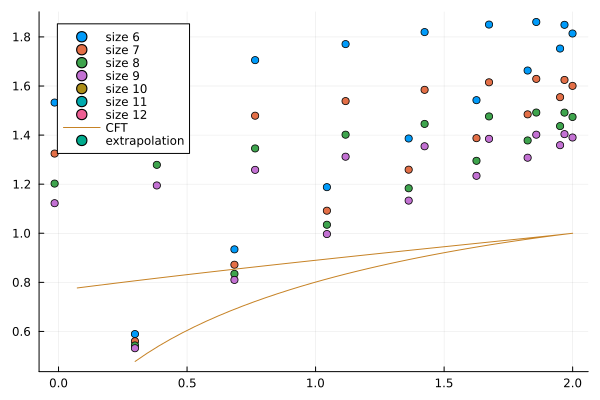

In [19]:
L = 6
r1, s1 = 1, 0
r2, s2 = 3//2, 0
r3, s3 = 1//2, 0
get_k_rs(r, s) = Int.((2*r, r*s))
res_file(L) = "../results/3pt/$(get_k_rs(r1, s1))_$(get_k_rs(r2, s2))_$(get_k_rs(r3, s3))_size_$L.jld2"
λ_min = load(res_file(L), "λ_min")
λ_step = load(res_file(L), "λ_step")
nb_values_λ = load(res_file(L), "nb_values_λ")
λrange = range(λ_min, step=λ_step, length=nb_values_λ)
beta(λ) = sqrt(4*λ/π)
ccs = [CentralCharge(:β, beta(λ)) for λ in λrange]
ns_lattice = [real(c.n) for c in ccs]
ω_lattice(L) = load(res_file(L), "ωs")

scatter()

Ls = Vector{Int}()

for L in 6:12
    try
        scatter!(ns_lattice, ω_lattice(L), label="size $L")
        push!(Ls, L)
    catch
        nothing
    end
end

# plot CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (r1, s1), (r2, s2), (r3, s3)) for c in cs])
plot!(ns, ω_CFT, label="CFT")

# Extrapolation
om(L, i) = ω_lattice(L)[i]
Ls = 5:10
poly_fit(i) = fit(1 ./ Ls, [om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]
scatter!(ns_lattice, extrapolated_points, label="extrapolation")

display(plot!())

### $(1, 1)(\frac12, 0)(\frac32, 0)$ WORKING - NO FACTORS OF $L$ NEEDED

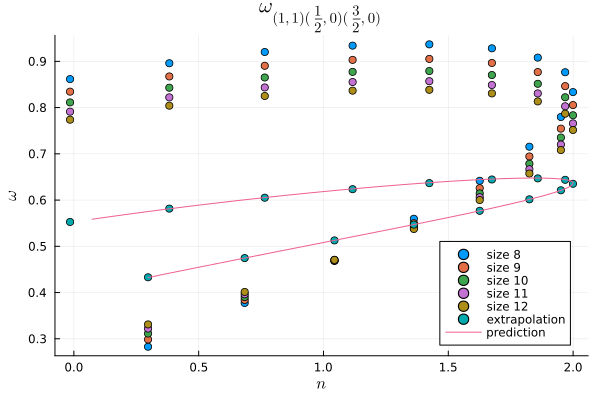

In [20]:
L = 6
r1, s1 = 1, 1
r2, s2 = 1//2, 0
r3, s3 = 3//2, 0
get_k_rs(r, s) = Int.((2*r, r*s))
res_file(L) = "../results/3pt/$(get_k_rs(r1, s1))_$(get_k_rs(r2, s2))_$(get_k_rs(r3, s3))_size_$L.jld2"
λ_min = load(res_file(L), "λ_min")
λ_step = load(res_file(L), "λ_step")
nb_values_λ = load(res_file(L), "nb_values_λ")
λrange = range(λ_min, step=λ_step, length=nb_values_λ)
beta(λ) = sqrt(4*λ/π)
ccs = [CentralCharge(:β, beta(λ)) for λ in λrange]
ns_lattice = [real(c.n) for c in ccs]
ω_lattice(L) = load(res_file(L), "ωs")

scatter(xlabel=L"n", ylabel=L"ω")

factor(L) = 3/2

Ls = Vector{Int}()
for L in 5:12
    try
        if L >= 8
            scatter!(ns_lattice, -factor(L) * ω_lattice(L), label="size $L")
        end
        push!(Ls, L)
    catch
        nothing
    end
end

# Extrapolation
om(L, i) = ω_lattice(L)[i]
poly_fit(i) = fit(1 ./ Ls, [-factor(L)*om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]
scatter!(ns_lattice, extrapolated_points, label="extrapolation")

# plot CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (r1, s1), (r2, s2), (r3, s3)) for c in cs])
plot!(ns, ω_CFT, label="prediction")

plot!(title=L"ω_{(1, 1)(\frac{1}{2}, 0)(\frac{3}{2}, 0)}")
display(plot!())

In [21]:
savefig("exported_figures/omega_11_120_320.pdf")

"/Users/paulroux/Documents/Recherche/projet_these/code/transfer_matrices/TransferMatricesCpp/On_loops/results/exported_figures/omega_11_120_320.pdf"

### $(1, 1)(1, 0)(1, 1)$

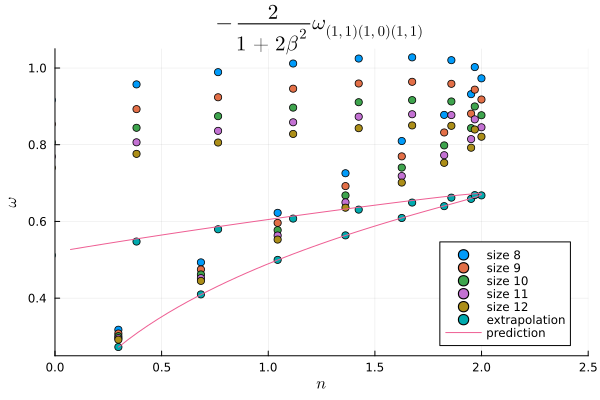

In [4]:
L = 6
r1, s1 = 1, 1
r2, s2 = 1, 0
r3, s3 = 1, 1
get_k_rs(r, s) = Int.((2*r, r*s))
res_file(L) = "../results/3pt/$(get_k_rs(r1, s1))_$(get_k_rs(r2, s2))_$(get_k_rs(r3, s3))_size_$L.jld2"
λ_min = load(res_file(L), "λ_min")
λ_step = load(res_file(L), "λ_step")
nb_values_λ = load(res_file(L), "nb_values_λ")
λrange = range(λ_min, step=λ_step, length=nb_values_λ)
beta(λ) = sqrt(4*λ/π)
ccs = [CentralCharge(:β, beta(λ)) for λ in λrange]
ns_lattice = [real(c.n) for c in ccs]
ω_lattice(L) = load(res_file(L), "ωs")

scatter(xrange = (0, 2.5), xlabel=L"n", ylabel=L"ω", title=L"- \frac{2}{1+2\beta^2} ω_{(1, 1)(1, 0)(1, 1)}")

Ls = Vector{Int}()

factor(L) = 1

for L in 6:13
    try
        if L >= 8
            scatter!(ns_lattice, factor(L) .* ω_lattice(L), label="size $L")
        end
        push!(Ls, L)
    catch
        nothing
    end
end

# Extrapolation
om(L, i) = ω_lattice(L)[i]
poly_fit(i) = fit(1 ./ Ls, [factor(L) .* om(L, i) for L in Ls])
extrapolated_points = [poly_fit(i)(0) for i in 1:16]
scatter!(ns_lattice, extrapolated_points, label="extrapolation")

# plot CFT prediction
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(c, (1, 1), (1, 0), (1, 1)) - omega(c, (1, 1), (1, 0), (1, -1)) for c in cs])
plot!(ns, ω_CFT, label="prediction")

display(plot!())

In [5]:
savefig("exported_figures/omega_11_10_11.pdf")

"/Users/paulroux/Documents/Recherche/projet_these/code/transfer_matrices/TransferMatricesCpp/On_loops/results/exported_figures/omega_11_10_11.pdf"

In [24]:
# relative difference
ω_11 = real.([omega(:β, β, (1, 0), (1, 1), (1, 1)) for β in beta.(λrange)])
ω_1m1 = real.([omega(:β, β, (1, 0), (1, 1), (1, -1)) for β in beta.(λrange)])
ω_CFT = ω_11 .- ω_1m1
diffs = abs.((ω_CFT .- extrapolated_points) ./ ω_CFT)
maximum(diffs)

0.01322040461172151497037261840601076198481318043375025233454818162176114244380784

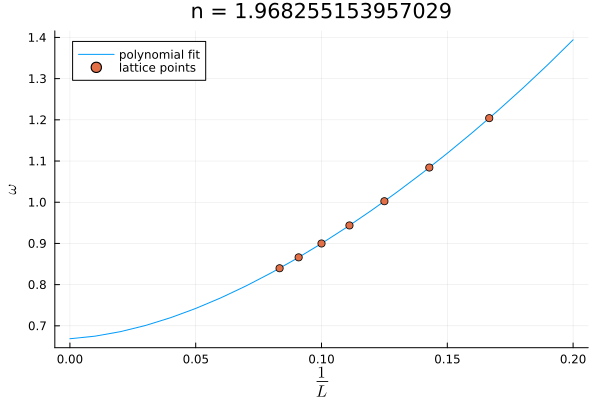

In [23]:
mesh=0:0.01:0.2
i=9
plt = plot(mesh, poly_fit(i).(mesh), label="polynomial fit")
scatter!(1 ./ Ls, [om(L, i) for L in Ls], label="lattice points")
plot!(xlabel=L"\frac{1}{L}", ylabel=L"\omega")
plot!(title="n = $(ns_lattice[i])")
display(plt)

In [24]:
extrapolated_points[8]

0.6679144829639635717922170289436944369220861828782692173222925380453513475797375

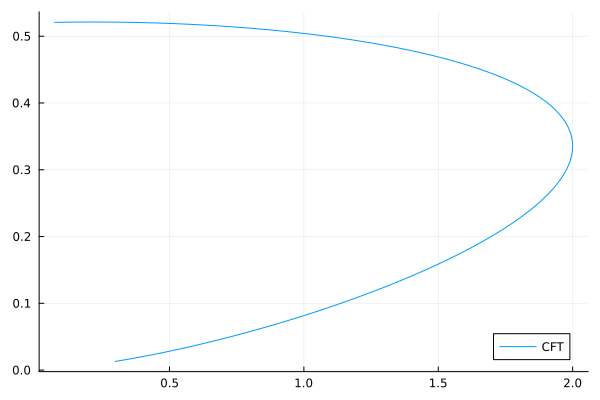

In [25]:
cs = [CentralCharge(:β, β) for β in 0.74:0.005:sqrt(1.5)]
ns = real.([c.n for c in cs])
ω_CFT = real.([omega(:β, β, (1, 0), (1, 1), (1, -1)) for β in 0.74:0.005:sqrt(1.5)])
plot(ns, ω_CFT, label="CFT")

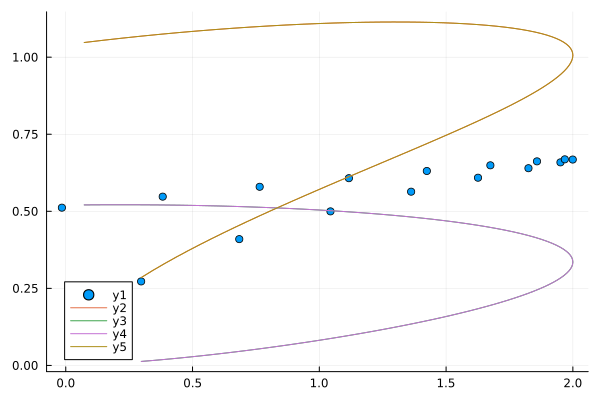

In [26]:
plot()
scatter!(ns_lattice, extrapolated_points)
for rs1 in ((1, 1), (1, -1)), rs2 in ((1, 1), (1, -1)), rs3 in ((1, 0),)
    plot!(ns, real.([omega(:β, β, rs1, rs2, rs3) for β in 0.74:0.005:sqrt(1.5)]))
end
display(plot!())

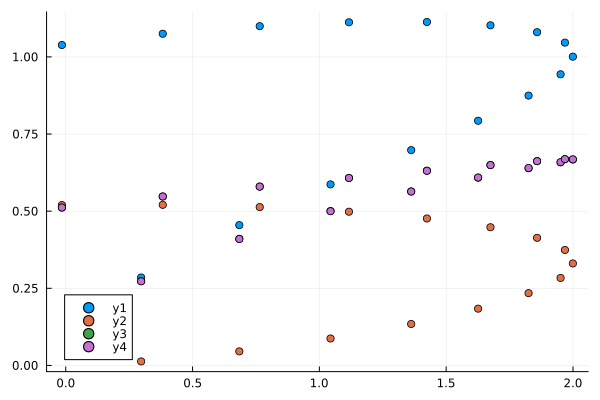

a = 1.005002693294232667187099581927714933592881282741498792476699763129656521130516, b = -1.023671783545185976871666589544555978922413667375586592002693293233955642413603


In [32]:
y1 = real.([omega(:β, β, (1, 0), (1, 1), (1, 1)) for β in beta.(λrange)])
y2 = real.([omega(:β, β, (1, 0), (1, 1), (1, -1)) for β in beta.(λrange)])

Y = hcat(y1, y2)
y_target = extrapolated_points

c = Y \ y_target
a, b = c[1], c[2]

scatter(ns_lattice, y1)
scatter!(ns_lattice, y2)
scatter!(ns_lattice, a .* y1 .+ b .* y2)
scatter!(ns_lattice, extrapolated_points)
display(plot!())

println("a = $a, b = $b")